In [2]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy import stats
import xarray as xr
import commondefs as myF
from mpl_toolkits.basemap import Basemap

plt.rcParams.update({'font.size': 10})

In [3]:
mydir = '../processed_netcdf/'

In [4]:
def is_feb(month):
    return month==2

def is_sep(month):
    return month==9

In [5]:
moddir = '../processed_netcdf/CMIP6_sivol_1979-2014_clim/'
allfiles = sorted([f for f in os.listdir(moddir) if 'sivol_SImon' in f and 'AWI' not in f])
names = [f.split('_')[2] for f in allfiles]

modnames = xr.open_dataset('../processed_netcdf/processed_CMIP6_sia_historical_r1_updated.nc').name.values
modnames = [f.strip().split('_')[0] for f in modnames]
names = [f for f in names if f in modnames]

nmod = len(names)
nmod

27

In [6]:
maps = [Basemap(projection='npstere', boundinglat=55, lon_0 = 0),Basemap(projection='spstere', boundinglat=-55, lon_0 = 180)]

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: MatplotlibDeprecationWarning: 
The dedent function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use inspect.cleandoc instead.
  """Entry point for launching an IPython kernel.


In [7]:
listds = []
lats = []
lons = []

for n,name in enumerate(names):
    ensfiles = [f for f in os.listdir(moddir) if name+'_' in f][0]
    ds = xr.open_dataset(moddir+ensfiles)
    listds.append(ds)
    lat,lon = myF.get_lats(ds)
    lats.append(lat)
    lons.append(lon)

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:17: RuntimeWarning: invalid value encountered in less
/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


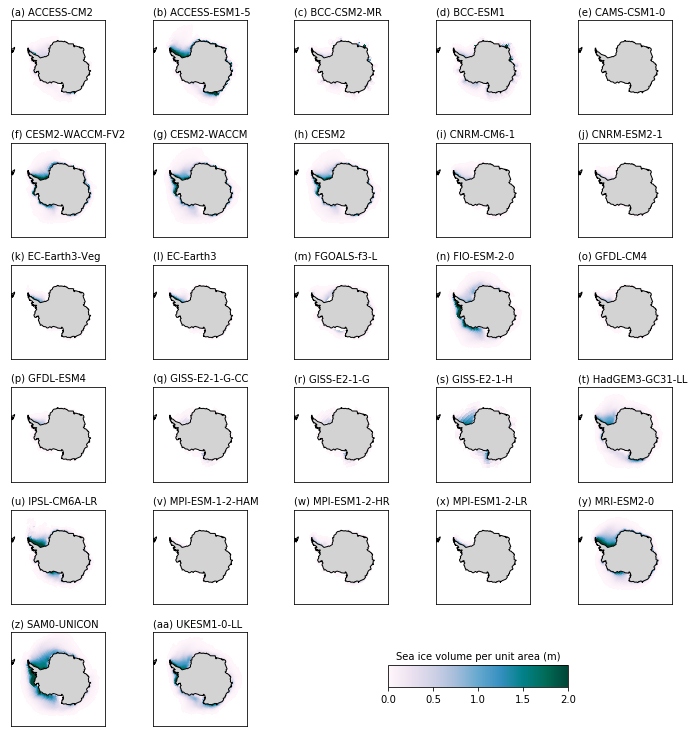

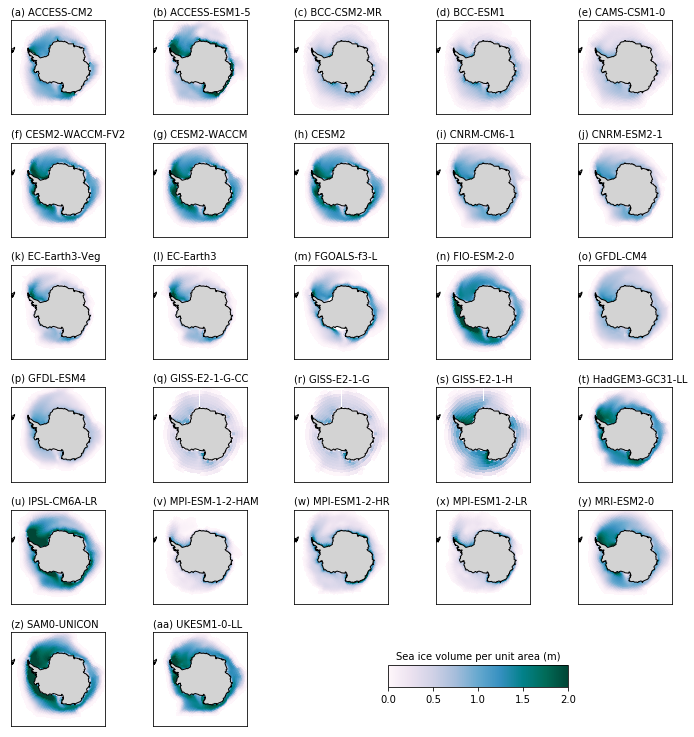

CPU times: user 41.6 s, sys: 767 ms, total: 42.3 s
Wall time: 24.2 s


In [8]:
%%time

h = 1
for ct, month in enumerate([1,8]):
    fig = plt.figure(figsize=(10,12))
    for mod in range(nmod):
        mydata = listds[mod].sivol
        ndims = len(mydata.shape)
        if ndims == 3:
            mydata = mydata[month,:,:]
        
            ax = plt.subplot(7,5,mod+1)
            ax.set_title(myF.alphabet[mod]+' '+names[mod],fontsize=10,loc='left')
            m = maps[h]
            x, y = m(lons[mod],lats[mod])

            mydata = ma.masked_where(lats[mod]>0,mydata)
            mydata = ma.masked_invalid(mydata)
            mydata = ma.masked_where(mydata<0.01,mydata)
            CS1 = m.pcolor(x,y,mydata,cmap = plt.cm.PuBuGn,vmin=0.,vmax=2.)       
            m.drawcoastlines(color='black')
            m.fillcontinents(color='lightgrey')
        else:
            print(names[mod])
        

    cbar_ax = fig.add_axes([0.55, 0.2, 0.25, 0.025]) #[left, bottom, width, height]
    cbar = fig.colorbar(CS1, cax=cbar_ax,  orientation='horizontal')
    cbar.ax.set_title(r'Sea ice volume per unit area (m)',fontsize=10)
    plt.tight_layout()
    
    fig.savefig('figS'+str(ct+4),bbox_inches='tight',dpi=600)
    plt.show()
    plt.close()